# Jacobian lens — walkthrough

Load a model, load a pre-fitted Jacobian lens from the Hub, apply it to a prompt, and render the interactive slice visualisation.

In [5]:
import pandas as pd

import jlens
jlens.configure_logging()

MODEL_NAME= "Qwen/Qwen3.5-4B"

LENS_REPO= "neuronpedia/jacobian-lens"
LENS_REVISION= "qwen-n1000"
LENS_FILE = {
    "Qwen/Qwen3.5-4B": "qwen3.5-4b/jlens/Salesforce-wikitext/Qwen3.5-4B_jacobian_lens_n1000.pt",
    "Qwen/Qwen3.6-27B": "qwen3.6-27b/jlens/Salesforce-wikitext/Qwen3.6-27B_jacobian_lens_n1000.pt",
}[MODEL_NAME]

## 1. Load the model

`jlens.from_hf` wraps an already-loaded HuggingFace model into `LensModel` interface

In [6]:
import torch
import transformers

hf_model = transformers.AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype=torch.bfloat16
).cuda()
tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL_NAME)
model = jlens.from_hf(hf_model, tokenizer)
model

Loading weights: 100%|██████████| 426/426 [00:00<00:00, 13247.82it/s]


HFLensModel(Qwen3_5ForCausalLM, n_layers=32, d_model=2560)

## 2. Load a pre-fitted lens

`JacobianLens.from_pretrained` pulls a `.pt` from the Hub (or a local path). The lens holds one `[d_model, d_model]` matrix per layer.

In [7]:
lens= jlens.JacobianLens.from_pretrained(
    LENS_REPO, filename=LENS_FILE, revision=LENS_REVISION
)
lens

Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 639.18it/s]


JacobianLens(d_model=2560, n_prompts=1000, source_layers=[0..30] (31 layers))

## 3. Apply: J-lens vs logit lens

`lens.apply(model, prompt, positions=...)` runs one forward pass, transports each layer's residual into the final-layer basis with `J_l`, and decodes through the model's own unembedding. `use_jacobian=False` skips the transport — that's the vanilla logit lens.

Below: a two-hop factual question, read out at the boot token. The J-lens surfaces interpretable tokens at layers where the logit lens is still noise.

In [8]:
prompt = "Fact: The currency used in the country shaped like a boot is"
layers = [
    model.n_layers // 4,
    model.n_layers // 2,
    model.n_layers // 4 * 3,
    model.n_layers - 2,
]

jlens_logits, model_logits, _ = lens.apply(model, prompt, layers=layers, positions=[-2])
logit_lens, _, _ = lens.apply(
    model, prompt, layers=layers, positions=[-2], use_jacobian=False
)


def top5(logits):
    return [tokenizer.decode([t]) for t in logits.topk(5).indices]


for layer in layers:
    print(f"L{layer:>3} logit-lens: {top5(logit_lens[layer][0])}")
    print(f"L{layer:>3} J-lens:     {top5(jlens_logits[layer][0])}")
print(f"model:           {top5(model_logits[0])}")

L  8 logit-lens: ['oman', 'edom', 'ולי', 'GPC', ' Urlaubs']
L  8 J-lens:     [' `', ' boots', ' *', ' `\\', ' heel']
L 16 logit-lens: ['shaw', 'วย', 'amaz', 'REA', '举世']
L 16 J-lens:     ['?', '？', "'?", '____', ' Italy']
L 24 logit-lens: ['的形状', '形状的', 'shape', '形状', '-shaped']
L 24 J-lens:     ['-shaped', ' shape', ' shaped', 'shape', '形状']
L 30 logit-lens: [' is', ' shape', '-shaped', ' heel', ' shaped']
L 30 J-lens:     [' is', ' shape', ' shaped', '-shaped', ' heel']
model:           [' is', ' in', ' on', '.', ' with']


## 4. Render a slice page (inline)

`compute_slice` + `build_page` produce an interactive position × layer view of the lens's token ranks (the `?` in the corner explains the controls). `mode="embed"` inlines everything so the page is self-contained.

In [9]:
import gzip
import json

from jlens.examples import EXAMPLES, resolve_prompt
from jlens.vis import build_page, compute_slice, notebook_iframe

# English gloss for Qwen's Chinese/Japanese/Korean vocab tokens (machine-
# generated, best-effort), shown next to
# the token in the page (alt_token=).
gloss = {
    int(k): v for k, v in json.load(gzip.open("assets/qwen_gloss.json.gz")).items()
}

example = next(e for e in EXAMPLES if e.slug == "multihop")
prompt = resolve_prompt(example, tokenizer)

slice_data = compute_slice(
    model,
    lens,
    prompt,
    layer_stride=2,
    # Empirically on Qwen, the interesting word tokens trail punctuation and
    # single-character tokens in the raw top-K; mask to word-like tokens only.
    mask_display=True,
)
page, _, _ = build_page(
    slice_data,
    prompt,
    title=example.section,
    description=example.description,
    alt_token=gloss,
)
notebook_iframe(page)

## 5. Render a slice page (served)

For longer prompts prefer `mode="fetch"`: `build_page` writes the data as sidecar files to `out_dir` and the page fetches rank files lazily on pin, so it stays small regardless of how many tokens are tracked.

In [10]:
import os
import threading
from functools import partial
from http.server import HTTPServer, SimpleHTTPRequestHandler
from pathlib import Path

example = next(e for e in EXAMPLES if e.slug == "ascii-face")
prompt = resolve_prompt(example, tokenizer)

slice_data = compute_slice(model, lens, prompt, mask_display=True)
out_dir = Path("slices") / example.slug
page, _, _ = build_page(
    slice_data,
    prompt,
    title=example.section,
    description=example.description,
    alt_token=gloss,
    mode="fetch",
    out_dir=out_dir,
)
(out_dir / "index.html").write_text(page, encoding="utf-8")

if "_jlens_httpd" not in globals():
    _handler = partial(SimpleHTTPRequestHandler, directory=os.path.abspath("slices"))
    _jlens_httpd = HTTPServer(("127.0.0.1", 0), _handler)
    threading.Thread(target=_jlens_httpd.serve_forever, daemon=True).start()
print(f"-> http://localhost:{_jlens_httpd.server_address[1]}/{example.slug}/")

-> http://localhost:52503/ascii-face/


Working with lens.apply for every source position

In [24]:
prompt= "What is the currecy of the country that has multiple cultures "
inputs= tokenizer(prompt, return_tensors="pt")
seq_len= inputs["input_ids"].shape[1]
positions= list(range(seq_len))
layers= lens.source_layers

jlens_logits, model_logits, _ = lens.apply(model, prompt, layers=layers, positions=positions)


for layer in layers:
    print(f"L{layer:>3} J-lens:     {top5(jlens_logits[layer][0])}")
print(f"model:           {top5(model_logits[0])}")





L  0 J-lens:     [' 「', " ''", ' ``', ' «', '\n\n']
L  1 J-lens:     [' ``', ' \ufeff', ' {{', " ''", ' Â']
L  2 J-lens:     [',', '\xa0', '<|endoftext|>', '»,', ' Â']
L  3 J-lens:     ['<|endoftext|>', ' \ufeff', ' 【', ' ``', ' 、']
L  4 J-lens:     ['<|endoftext|>', ' —', '?', '\u3000', ' 【']
L  5 J-lens:     ['<|endoftext|>', ' —', ' ?', '?', '\u3000']
L  6 J-lens:     ['<|endoftext|>', ' ...', ' ``', '\n\n', '\n']
L  7 J-lens:     ['<|endoftext|>', ' ...', ' ?', '<|im_end|>', '\n\n']
L  8 J-lens:     ['<|endoftext|>', ' ...', ' ?', '\n\n', '<|im_end|>']
L  9 J-lens:     ['<|endoftext|>', ' ...', '\n\n', ' ?', '<|im_end|>']
L 10 J-lens:     ['\n\n', '\n \n', ' \n\n', '\n', '<|im_end|>']
L 11 J-lens:     ['\n\n', ' ``', ' ?', ' \n\n', ' **']
L 12 J-lens:     [' \n\n', ' \n', '\n\n', '<|im_end|>', ' **']
L 13 J-lens:     [' **', ' **“', '?**', '？**', '?”']
L 14 J-lens:     [' **“', ' **„', ' **', ' **«', ' **+']
L 15 J-lens:     [' **', ' **“', '？**', '**?', ' **„']
L 16 J-lens:     ['

#Visualization
Slice-vis-grid

In [27]:
slice_data= compute_slice(model, lens, prompt, mask_display=True)
page, _, _ = build_page(
    slice_data,
    prompt,
    title= "Multihop",
    description="test",
    alt_token=gloss
)
notebook_iframe(page)

##Bulk Application Experimentation

In [37]:
import pandas as pd
file= "data/experiments/directed-modulation.json"

with open(file,"r") as f:
    data= json.load(f)

MAX_PROMPTS= 15
print(data)
prompts= [item["text"] for item in data["phrasings"]][:MAX_PROMPTS]

result=[]

for i,prompt in enumerate(prompts):
    print(f"{i+1}/{len(prompts)} processing...")

    seq_data= compute_slice(model, lens, prompt, mask_display=True)
    seq_len= seq_data.seq_len


    for j in range(seq_len):
        for idx,num in enumerate(layers):
            top_id= seq_data.top_ids[j,idx,0]
            top_rank= seq_data.top_ranks[j,idx,0]
            top_str= seq_data.vocab_fragment[top_id]


            result.append({
                "prompt_id": i,
                "position":j,
                "rank":top_rank,
                "layer":num,
                "top_10_token": top_str,


            })
print("Data Processed")
df= pd.DataFrame(result)
print(df)


{'phrasings': [{'name': 'foc_think', 'group': 'focus', 'text': 'Think about {x} while you write.'}, {'name': 'foc_concentrate', 'group': 'focus', 'text': 'Concentrate on {x} while you write the sentence.'}, {'name': 'foc_focus', 'group': 'focus', 'text': 'Try to focus on {x} while you write the sentence.'}, {'name': 'foc_hold', 'group': 'focus', 'text': 'Hold {x} in mind as you write.'}, {'name': 'foc_keep', 'group': 'focus', 'text': 'Keep {x} in your thoughts.'}, {'name': 'dis_irrelevant', 'group': 'dismissal', 'text': '{x} is irrelevant â€” ignore it.'}, {'name': 'dis_irrelevant_t', 'group': 'dismissal', 'text': '{x} is irrelevant.'}, {'name': 'dis_ignore', 'group': 'dismissal', 'text': 'Ignore {x}.'}, {'name': 'dis_paren', 'group': 'dismissal', 'text': '(Ignore: {x}.)'}, {'name': 'dis_distraction', 'group': 'dismissal', 'text': '{x} is a distraction â€” push it out of your mind.'}, {'name': 'dis_unrelated', 'group': 'dismissal', 'text': '{x} is unrelated to this task.'}, {'name': 'n

## Aggregate and Visualize

In [40]:
layer_summary= df.groupby('layer').agg(
    avg_rank=('rank', 'mean'),
    median_rank= ('rank', 'median'),
    top_hits= ('rank', lambda x: (x==0).mean())
).reset_index()

print("Per layer Summary")
display(layer_summary)

Per layer Summary


,layer,avg_rank,median_rank,top_hits
0,0,13.389706,4.0,0.257353
1,1,28.110294,14.0,0.102941
2,2,8.500000,2.5,0.294118
3,3,16.330882,6.0,0.161765
4,4,16.867647,7.5,0.183824
5,5,16.235294,8.5,0.176471
6,6,19.492647,9.0,0.117647
7,7,19.580882,13.5,0.125000
8,8,20.992647,11.0,0.139706
9,9,27.279412,15.5,0.066176


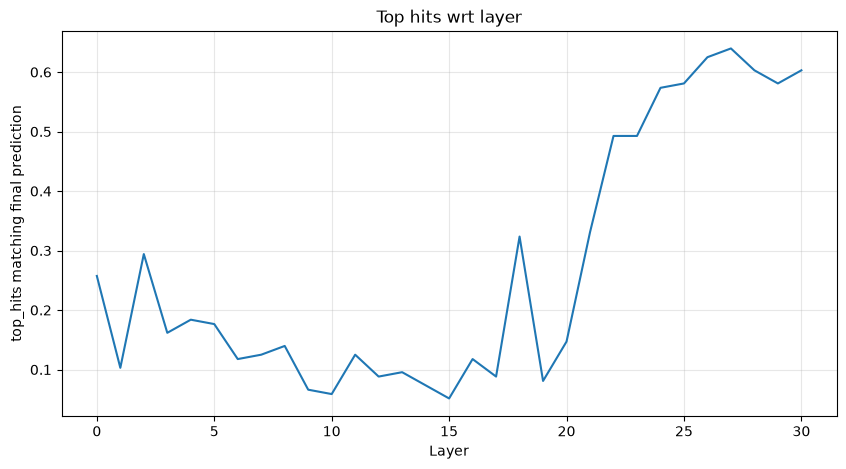

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(layer_summary["layer"], layer_summary["top_hits"])
plt.title("Top hits wrt layer")
plt.xlabel("Layer")
plt.ylabel("top_hits matching final prediction")
plt.grid(True, alpha=0.3)
plt.show()
